# Options: implied-vol surfaces as versioned marks

A vol desk's surface is not one object - it is a *sequence* of marks: EOD
snapshots, intraday re-marks, corrections. Storing each chain snapshot as an
h5i-db commit gives you the whole sequence with O(1) access to any of them:
`h5i('chain', v)` in SQL is "the surface as it was marked at T", which is
exactly the question risk, P&L-explain and model-validation keep asking.

The table layout showcases a detail worth copying: **both** `ts` (mark time)
and `expiry` are `timestamp[us, UTC]` columns - tenor is always *derived*
(`expiry - ts`), never stored, so it can never go stale as the clock moves.

We store 5 daily SPX-style chain snapshots, extract ATM term structure and
25-delta risk reversals / butterflies in SQL, draw the surface, then use
versioning to answer "what did the desk see at yesterday's close?"

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, count_star, sql_expr
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_options"), create=True)

chain = cu.make_option_chain(snapshots=5)  # ts, underlier, expiry, strike, cp, iv, mid, delta
chain.schema

ts: timestamp[us, tz=UTC]
underlier: string
expiry: timestamp[us, tz=UTC]
strike: double
cp: string
iv: double
mid: double
delta: double

## 1. One snapshot day = one commit

`sort_key` starts with the time column (required) and then orders each
snapshot by expiry and strike - the natural scan order for surface queries.
Appending day by day makes every EOD mark its own version, with a `note`
that becomes the audit trail.

In [2]:
db.create_table("chain", chain.schema, time_column="ts", sort_key=["ts", "expiry", "strike"])

chain_df = chain.to_pandas()
for day_ts, day_chain in chain_df.groupby("ts"):
    db.append(
        "chain",
        pa.Table.from_pandas(day_chain, schema=chain.schema, preserve_index=False),
        note=f"EOD marks {day_ts.date()}",
    )

[
    {k: v[k] for k in ("sequence", "op", "rows", "note") if k in v}
    for v in db.versions("chain")
]

[{'sequence': 0, 'op': 'create', 'rows': 0},
 {'sequence': 1, 'op': 'append', 'rows': 238, 'note': 'EOD marks 2026-06-01'},
 {'sequence': 2, 'op': 'append', 'rows': 476, 'note': 'EOD marks 2026-06-02'},
 {'sequence': 3, 'op': 'append', 'rows': 714, 'note': 'EOD marks 2026-06-03'},
 {'sequence': 4, 'op': 'append', 'rows': 952, 'note': 'EOD marks 2026-06-04'},
 {'sequence': 5, 'op': 'append', 'rows': 1190, 'note': 'EOD marks 2026-06-05'}]

## 2. Recover spot from put-call parity

The chain carries no spot column - and it doesn't need one. With zero rates
(as in this generator), parity gives `C - P = S - K`, so `S = K + C - P` for
every strike. Averaging across the chain recovers the forward/spot per mark
date to within quote-rounding noise; we reuse it below to put strikes on a
moneyness axis.

In [3]:
# Put-call parity as a self-join: the calls frame joined to the puts frame on
# (ts, expiry, strike). Holding each side in a variable is what makes the
# self-join readable.
calls = db.table("chain").filter(col("cp") == "C")
puts = db.table("chain").filter(col("cp") == "P")

SPOT = (
    calls.join(puts, on=["ts", "expiry", "strike"])
    .group_by(col("ts", relation="l").alias("ts"))
    .agg(
        spot=(
            col("strike", relation="l") + col("mid", relation="l") - col("mid", relation="r")
        ).mean()
    )
)

spot = SPOT.sort("ts").to_pandas()
spot

,ts,spot
0,2026-06-01 20:00:00+00:00,5546.520000
1,2026-06-02 20:00:00+00:00,5516.437143
2,2026-06-03 20:00:00+00:00,5370.207563
3,2026-06-04 20:00:00+00:00,5395.000168
4,2026-06-05 20:00:00+00:00,5336.681681


## 3. ATM term structure per mark date

For each `(ts, expiry)` we rank call strikes by distance to spot and keep
the nearest - a window function over the parity-spot CTE. Tenor is derived
in pandas from the two timestamp columns.

In [4]:
# The parity spot frame is reused here rather than re-written: join it back
# to the call chain, then rank strikes by moneyness distance.
atm = (
    calls.join(SPOT, on="ts")
    .select(
        ts=col("ts", relation="l"),
        expiry=col("expiry", relation="l"),
        atm_iv=col("iv", relation="l"),
        spot=col("spot", relation="r"),
        moneyness_gap=(col("strike", relation="l") / col("spot", relation="r") - 1).abs(),
    )
    .with_columns(
        rn=sql_expr("row_number()").over(
            partition_by=["ts", "expiry"], order_by="moneyness_gap"
        )
    )
    .filter(col("rn") == 1)
    .select("ts", "expiry", "atm_iv", "spot")
    .sort(["ts", "expiry"])
    .to_pandas()
)
atm["tenor_d"] = (atm["expiry"] - atm["ts"]).dt.days
atm.head(7)

,ts,expiry,atm_iv,spot,tenor_d
0,2026-06-01 20:00:00+00:00,2026-06-08 00:00:00+00:00,0.1940,5546.52,6
1,2026-06-01 20:00:00+00:00,2026-06-15 00:00:00+00:00,0.1939,5546.52,13
2,2026-06-01 20:00:00+00:00,2026-07-01 00:00:00+00:00,0.1955,5546.52,29
3,2026-06-01 20:00:00+00:00,2026-07-31 00:00:00+00:00,0.1897,5546.52,59
4,2026-06-01 20:00:00+00:00,2026-08-31 00:00:00+00:00,0.1908,5546.52,90
5,2026-06-01 20:00:00+00:00,2026-11-30 00:00:00+00:00,0.1954,5546.52,181
6,2026-06-01 20:00:00+00:00,2027-06-01 00:00:00+00:00,0.1914,5546.52,364


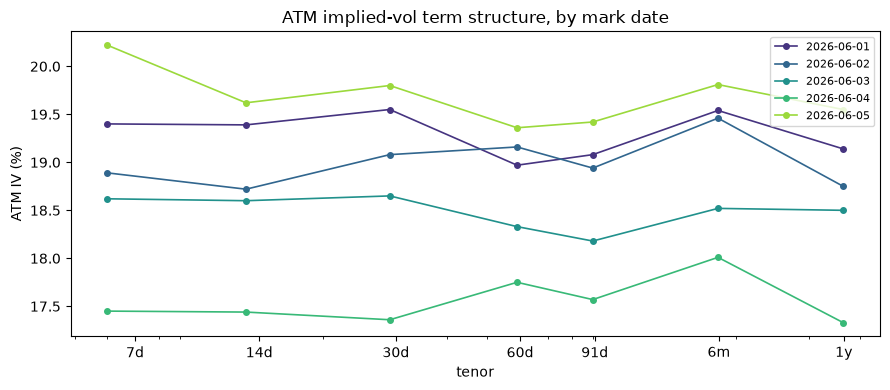

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
dates = sorted(atm["ts"].unique())
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(dates)))
for d, c in zip(dates, colors):
    g = atm[atm["ts"] == d]
    ax.plot(g["tenor_d"], 100 * g["atm_iv"], marker="o", ms=4, lw=1.2,
            color=c, label=str(pd.Timestamp(d).date()))
ax.set_xscale("log")
ax.set_xticks([7, 14, 30, 60, 91, 182, 365])
ax.set_xticklabels(["7d", "14d", "30d", "60d", "91d", "6m", "1y"])
ax.set_title("ATM implied-vol term structure, by mark date")
ax.set_xlabel("tenor")
ax.set_ylabel("ATM IV (%)")
ax.legend(fontsize=8)
fig.tight_layout()

## 4. 25-delta risk reversal and butterfly

The chain stores deltas, so the standard skew summary is three window ranks:
nearest-to-+0.25 call, nearest-to-−0.25 put, nearest-to-0.50 call (ATM).
`RR = σ_25C − σ_25P` (skew direction), `BF = ½(σ_25C + σ_25P) − σ_ATM`
(wing convexity). On short tenors the strike grid is coarse in delta space -
"nearest to 25Δ" can be a fair distance from 25Δ, as on any real listed
chain, so read the short end with that in mind.

In [6]:
# Three ranked CTEs joined pairwise: .join() is binary and aliases each side
# l/r, so a three-way join would nest into unreadable qualifiers. SQL wins.
rr_bf = db.sql(
    """
    WITH c25 AS (SELECT ts, expiry, iv,
                        row_number() OVER (PARTITION BY ts, expiry ORDER BY abs(delta - 0.25)) AS rn
                 FROM chain WHERE cp = 'C'),
         p25 AS (SELECT ts, expiry, iv,
                        row_number() OVER (PARTITION BY ts, expiry ORDER BY abs(delta + 0.25)) AS rn
                 FROM chain WHERE cp = 'P'),
         atm AS (SELECT ts, expiry, iv,
                        row_number() OVER (PARTITION BY ts, expiry ORDER BY abs(delta - 0.50)) AS rn
                 FROM chain WHERE cp = 'C')
    SELECT c.ts, c.expiry,
           c.iv - p.iv                  AS rr25,
           0.5 * (c.iv + p.iv) - a.iv   AS bf25,
           a.iv                         AS atm_iv
    FROM c25 c
    JOIN p25 p ON c.ts = p.ts AND c.expiry = p.expiry
    JOIN atm a ON c.ts = a.ts AND c.expiry = a.expiry
    WHERE c.rn = 1 AND p.rn = 1 AND a.rn = 1
    ORDER BY c.ts, c.expiry
    """
).to_pandas()
rr_bf["tenor_d"] = (rr_bf["expiry"] - rr_bf["ts"]).dt.days

latest_ts = rr_bf["ts"].max()
rr_bf[rr_bf["ts"] == latest_ts][["tenor_d", "atm_iv", "rr25", "bf25"]].round(4)

,tenor_d,atm_iv,rr25,bf25
28,6,0.2022,1.1414,0.6086
29,13,0.1962,-0.0233,0.0144
30,29,0.1980,-0.0444,0.0216
31,59,0.1936,-0.0202,0.0128
32,90,0.1942,-0.0336,0.0198
33,181,0.1981,-0.0296,0.0145
34,364,0.1941,-0.0259,0.0146


## 5. The surface, moneyness × tenor

One mark date, calls only. Within a snapshot every expiry shares the same
strike grid, so a pivot gives a clean rectangular surface; the parity spot
converts strikes to moneyness. `pcolormesh` with a perceptually-uniform
sequential colormap - IV is a magnitude, so one hue, light-to-dark.

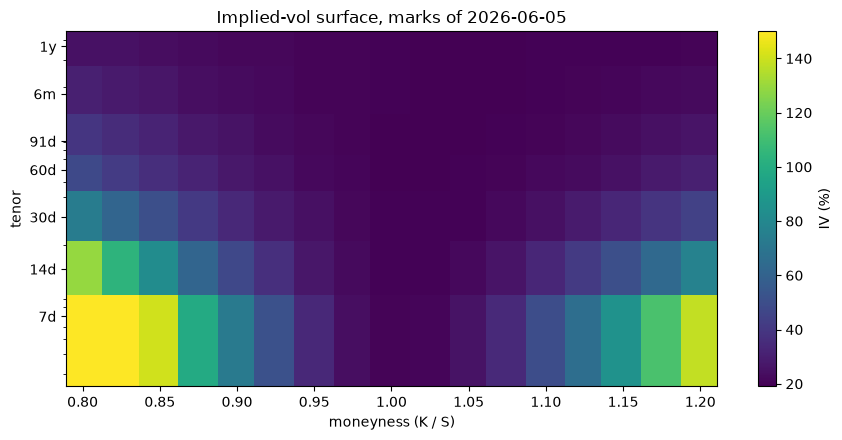

In [7]:
day_spot = float(spot.loc[spot["ts"] == latest_ts, "spot"].iloc[0])
surf = chain_df[(chain_df["ts"] == latest_ts) & (chain_df["cp"] == "C")].copy()
surf["tenor_d"] = (surf["expiry"] - surf["ts"]).dt.days
surf["moneyness"] = surf["strike"] / day_spot
grid = surf.pivot_table(index="tenor_d", columns="moneyness", values="iv")

fig, ax = plt.subplots(figsize=(9, 4.5))
pcm = ax.pcolormesh(grid.columns, grid.index, 100 * grid.values,
                    cmap="viridis", shading="nearest")
ax.set_yscale("log")
ax.set_yticks([7, 14, 30, 60, 91, 182, 365])
ax.set_yticklabels(["7d", "14d", "30d", "60d", "91d", "6m", "1y"])
ax.set_title(f"Implied-vol surface, marks of {pd.Timestamp(latest_ts).date()}")
ax.set_xlabel("moneyness (K / S)")
ax.set_ylabel("tenor")
fig.colorbar(pcm, ax=ax, label="IV (%)")
fig.tight_layout()

## 6. Smile evolution across the week

The 30-day smile from each of the five snapshots, overlaid. Each day the
chain re-lists a fresh 30d expiry, so we select by *derived* tenor - one
more payoff of keeping `expiry` as a timestamp rather than storing a tenor
label that drifts.

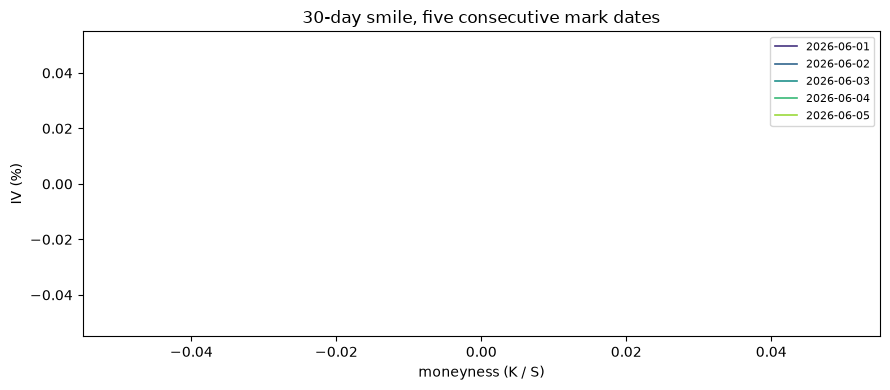

In [8]:
smiles = chain_df[chain_df["cp"] == "C"].copy()
smiles["tenor_d"] = (smiles["expiry"] - smiles["ts"]).dt.days
smiles = smiles[smiles["tenor_d"] == 30].merge(spot, on="ts")
smiles["moneyness"] = smiles["strike"] / smiles["spot"]

fig, ax = plt.subplots(figsize=(9, 4))
for d, c in zip(dates, colors):
    g = smiles[smiles["ts"] == d].sort_values("moneyness")
    ax.plot(g["moneyness"], 100 * g["iv"], lw=1.2, color=c, label=str(pd.Timestamp(d).date()))
ax.set_title("30-day smile, five consecutive mark dates")
ax.set_xlabel("moneyness (K / S)")
ax.set_ylabel("IV (%)")
ax.legend(fontsize=8)
fig.tight_layout()

## 7. As-of queries: the surface as marked at T

Because each snapshot is a commit, "the surface the desk saw at the close of
day 2" is not a filter - it is a *version*. `h5i('chain', 2)` returns the
table exactly as it stood after the day-2 commit; the day-3..5 marks do not
exist in that view. The wall-clock variant `read(as_of=...)` answers the
same question by commit time, which is what an auditor will hand you.

In [9]:
db.sql(
    """
    SELECT 'as of v2 (day-2 close)' AS view, count(*) AS rows, max(ts) AS latest_mark
    FROM h5i('chain', 2)
    UNION ALL
    SELECT 'head', count(*), max(ts) FROM chain
    """
).to_pandas()

,view,rows,latest_mark
0,as of v2 (day-2 close),476,2026-06-02 20:00:00+00:00
1,head,1190,2026-06-05 20:00:00+00:00


In [10]:
v3_commit_iso = pd.Timestamp(db.versions("chain")[3]["committed_at_ns"], unit="ns", tz="UTC").isoformat()
as_of_v3 = db.read("chain", as_of=v3_commit_iso)
print(f"read(as_of='{v3_commit_iso}') -> {as_of_v3.num_rows} rows,",
      f"latest mark {pd.Timestamp(pa.compute.max(as_of_v3['ts']).as_py()).date()}")

read(as_of='2026-07-27T02:38:44.516568005+00:00') -> 714 rows, latest mark 2026-06-03


## 8. Intraday re-marks are just more versions

Late in day 5 the desk bumps vols 6% (risk-off re-mark) and commits the new
marks 30 minutes after the close. Append semantics allow it - the re-mark
timestamps are later than the EOD ones - and now two generations of day-5
marks coexist in the head. The desk's two standing questions become two
one-liners:

- *current* surface → latest mark per contract (a window dedup);
- *as marked at the close* → `h5i('chain', 5)`, frozen forever.

In [11]:
day5 = chain_df[chain_df["ts"] == latest_ts].copy()
remark = day5.assign(ts=day5["ts"] + pd.Timedelta(minutes=30), iv=(day5["iv"] * 1.06).round(4))
db.append("chain", pa.Table.from_pandas(remark, schema=chain.schema, preserve_index=False),
          note="intraday re-mark day 5 (+6% vol)")

day5_us = int(pd.Timestamp(latest_ts).value // 1000)
db.sql(
    f"""
    WITH latest AS (
        SELECT iv, row_number() OVER (PARTITION BY expiry, strike, cp ORDER BY ts DESC) AS rn
        FROM chain
        WHERE ts >= to_timestamp_micros({day5_us})
    )
    SELECT 'current (post re-mark)' AS view, avg(iv) AS avg_iv
    FROM latest WHERE rn = 1
    UNION ALL
    SELECT 'as marked at day-5 close', avg(iv)
    FROM h5i('chain', 5) WHERE ts >= to_timestamp_micros({day5_us})
    """
).to_pandas().round(4)

,view,avg_iv
0,as marked at day-5 close,0.3630
1,current (post re-mark),0.3848


## Takeaways

- Model `expiry` as a `timestamp[us, UTC]` column next to the mark time
  `ts`: tenor, moneyness and "which listed expiry is ~30d today" are all
  derived, never stale.
- One chain snapshot per commit turns `versions()` into the desk's marking
  history, and `h5i('chain', v)` / `read(as_of=...)` into instant
  "surface as marked at T" queries - no bitemporal bookkeeping tables.
- Window functions do the surface analytics in SQL: nearest-to-spot rank
  for ATM, nearest-to-25Δ ranks for risk reversal and butterfly, a
  `row_number ... ORDER BY ts DESC` dedup for latest-mark-per-contract.
- Put-call parity recovers spot from the chain itself - one fewer join
  against a spot feed in every surface query.
- Intraday re-marks are ordinary appends; the close marks stay frozen at
  their version while the head reflects the latest generation.

In [12]:
db.close()